In [1]:
import scipy.io as sio
import numpy as np  
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
catalog = np.loadtxt('../data/Geysers/raw/geysers_catalog.dat')
Inj = pd.read_csv('../data/Geysers/raw/InjData.csv')

In [3]:
# reference date (same baseline as the seismic data)
jd0 = pd.Timestamp('2003-05-01')
Inj['Date'] = pd.to_datetime(Inj['Date'])
# ensure Date is datetime and compute time t in days since jd0
Inj = Inj[Inj['Date']>=jd0].copy()
Inj['t'] = (Inj['Date'] - jd0).dt.total_seconds() / 86400.0

In [4]:
Inj['ProdVol'] = Inj['ProdVol']/10**5  
Inj['InjVol'] = Inj['InjVol']/10**5    

In [5]:
Inj['days_in_month'] = Inj['Date'].dt.days_in_month

In [6]:
Inj

,Date,ProdVol,InjVol,t,days_in_month
412,2003-05-31,50.74228,33.01976,30.0,31
413,2003-06-30,50.75838,18.73602,60.0,30
414,2003-07-31,52.34909,14.39230,91.0,31
415,2003-08-31,51.50224,15.79554,122.0,31
416,2003-09-30,49.49692,15.31483,152.0,30
...,...,...,...,...,...
548,2014-09-30,46.75000,21.48566,4170.0,30
549,2014-10-31,47.70636,26.71851,4201.0,31
550,2014-11-30,46.39368,29.96102,4231.0,30
551,2014-12-31,46.26131,47.17368,4262.0,31


In [7]:
Inj['days_in_month'] = Inj['Date'].dt.days_in_month
Inj['ProdVol_per_day'] = Inj['ProdVol'] / Inj['days_in_month']
Inj['InjVol_per_day'] = Inj['InjVol'] / Inj['days_in_month']

daily_parts = []
for _, r in Inj.iterrows():
    start_day = r['Date'].replace(day=1)
    end_day = r['Date']
    days = pd.date_range(start=start_day, end=end_day, freq='D')
    df_days = pd.DataFrame(index=days)
    df_days['ProdVol_daily'] = r['ProdVol_per_day']
    df_days['InjVol_daily'] = r['InjVol_per_day']
    daily_parts.append(df_days)
daily_df = pd.concat(daily_parts).sort_index()
daily_df = daily_df.groupby(daily_df.index).sum()
daily_df['Date'] = daily_df.index

Inj[['Date', 'days_in_month', 'ProdVol_per_day', 'InjVol_per_day']].head()
daily_df['t'] = (daily_df.index - jd0).total_seconds() / 86400.0

In [8]:
daily_df.columns

Index(['ProdVol_daily', 'InjVol_daily', 'Date', 't'], dtype='object')

In [9]:
daily_df.to_csv('../data/Geysers/raw/daily_injection_production.csv')

In [ ]:
daily_df

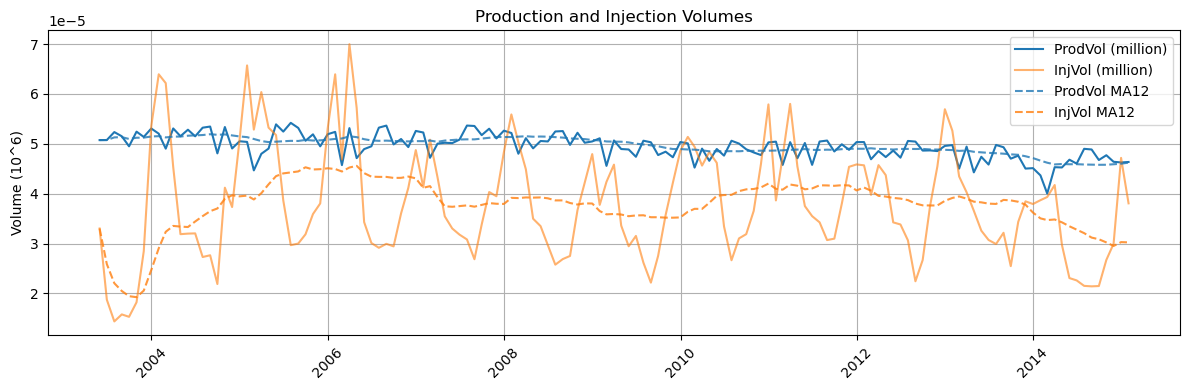

In [10]:
import matplotlib.dates as mdates

Inj_plot = Inj.copy()
Inj_plot['Date'] = pd.to_datetime(Inj_plot['Date'])
Inj_plot.set_index('Date', inplace=True)

Inj_plot[['ProdVol_MA12', 'InjVol_MA12']] = Inj_plot[['ProdVol', 'InjVol']].rolling(12, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(12,4))
ax.plot(Inj_plot.index, Inj_plot['ProdVol']/1e6, label='ProdVol (million)', color='C0')
ax.plot(Inj_plot.index, Inj_plot['InjVol']/1e6, label='InjVol (million)', color='C1', alpha=0.6)
ax.plot(Inj_plot.index, Inj_plot['ProdVol_MA12']/1e6, '--', label='ProdVol MA12', color='C0', alpha=0.8)
ax.plot(Inj_plot.index, Inj_plot['InjVol_MA12']/1e6, '--', label='InjVol MA12', color='C1', alpha=0.8)

ax.set_ylabel('Volume (10^6)')
ax.set_title('Production and Injection Volumes')
ax.legend()
ax.grid(True)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
plt.tight_layout()

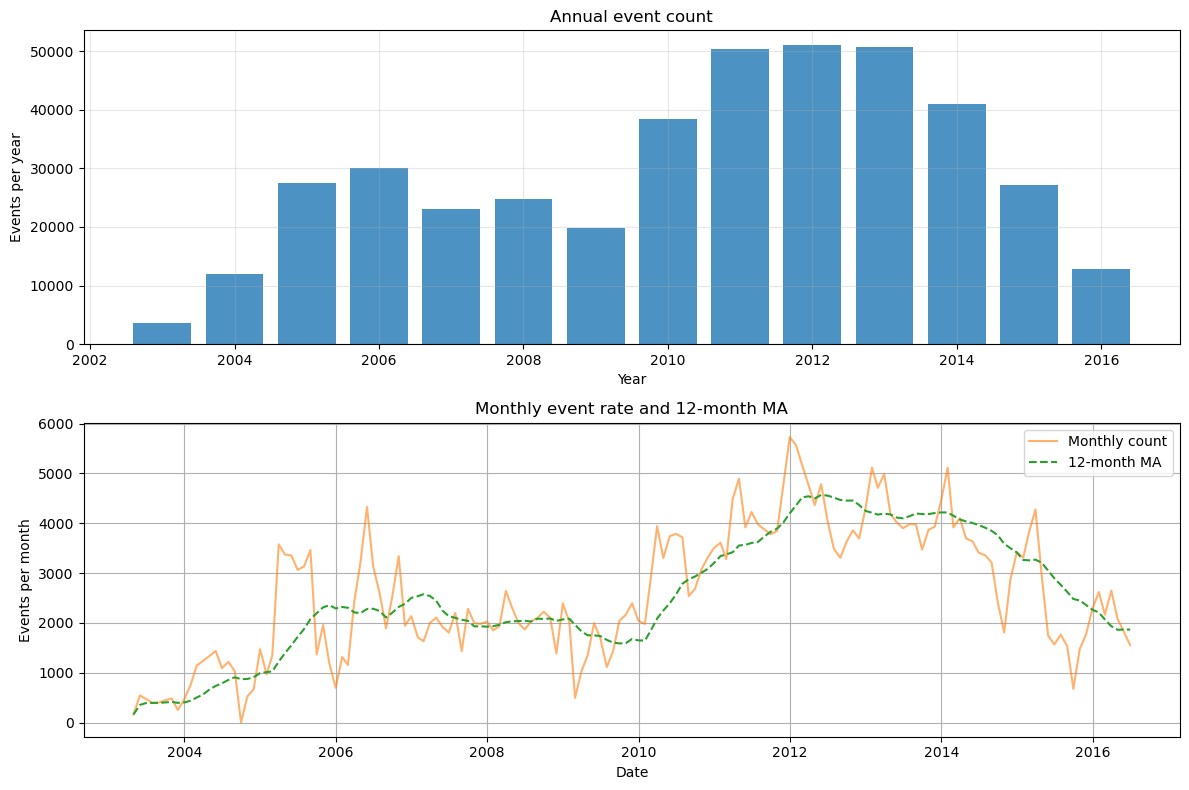

In [11]:
df_cat = pd.DataFrame(catalog)
df_cat['date'] = pd.to_datetime(dict(year=df_cat[0].astype(int),
                                     month=df_cat[1].astype(int),
                                     day=df_cat[2].astype(int)))

events_per_year = df_cat.set_index('date').resample('YE').size()

events_per_month = df_cat.set_index('date').resample('ME').size()
events_month_ma12 = events_per_month.rolling(12, min_periods=1).mean()

fig2, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,8), sharex=False)

ax1.bar(events_per_year.index.year, events_per_year.values, color='C0', alpha=0.8)
ax1.set_title('Annual event count')
ax1.set_xlabel('Year')
ax1.set_ylabel('Events per year')
ax1.grid(True, alpha=0.3)

ax2.plot(events_per_month.index, events_per_month.values, label='Monthly count', color='C1', alpha=0.6)
ax2.plot(events_month_ma12.index, events_month_ma12.values, '--', label='12-month MA', color='C2')
ax2.set_title('Monthly event rate and 12-month MA')
ax2.set_xlabel('Date')
ax2.set_ylabel('Events per month')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [12]:
import src.features.seismic_features as sf
dat_file = '../data/Geysers/raw/geysers_catalog.dat'
column_names = ['Year', 'Month', 'Day', 'Hour', 'Minute', 'Second', 'Latitude', 'Longitude', 'Magnitude','Depth']
df = pd.read_csv(dat_file, header=None, names=column_names, sep=r'\s+')
df['ts'] = pd.to_datetime(
    df[['Year', 'Month', 'Day', 'Hour', 'Minute']].assign(Second=df['Second']),
    errors='coerce'  
)
data_input = df.to_numpy()
year = data_input[:, 0].astype(int)
month = data_input[:, 1].astype(int)
day = data_input[:, 2].astype(int)
hour = data_input[:, 3].astype(int)
minute = data_input[:, 4].astype(int)
second = data_input[:, 5]

data = np.column_stack((year, month, day, hour, minute, second))
jd0 = sf.cal2jd([2003, 5, 1, 0, 0, 0])
jd = np.array([sf.cal2jd(d) - jd0 for d in data])

df.loc[:, 't'] = jd
df = df[['t', 'Magnitude', 'Latitude', 'Longitude', 'Depth', 'ts']]
csv_file = os.path.splitext(dat_file)[0] + '.csv'
start_date = pd.to_datetime('2003-05-01')
end_date = pd.to_datetime('2015-01-31')
df = df.sort_values(by='t').reset_index(drop=True)
df['dt'] = df['t'].diff().fillna(0)
filtered_df = df[(df['ts'] >= start_date) & (df['ts'] <= end_date)]
filtered_df.to_csv(csv_file, index=False)

In [13]:
filtered_df

,t,Magnitude,Latitude,Longitude,Depth,ts,dt
163,0.074852,1.11,38.7569,-122.7283,0.94,2003-05-01 01:47:47.240,0.087480
164,0.074963,1.27,38.7563,-122.7285,1.02,2003-05-01 01:47:56.800,0.000111
165,0.089139,1.56,38.7993,-122.7715,3.15,2003-05-01 02:08:21.640,0.014176
166,0.130171,1.05,38.7754,-122.7493,0.95,2003-05-01 03:07:26.770,0.041032
167,0.145542,1.84,38.7855,-122.7746,0.95,2003-05-01 03:29:34.830,0.015371
...,...,...,...,...,...,...,...
375511,4292.966605,0.71,38.8263,-122.8130,2.21,2015-01-30 23:11:54.660,0.017610
375512,4292.973255,1.73,38.8255,-122.7920,3.88,2015-01-30 23:21:29.230,0.006650
375513,4292.973819,1.47,38.8412,-122.8178,3.21,2015-01-30 23:22:18.000,0.000564
375514,4292.978858,1.39,38.6660,-122.6977,13.00,2015-01-30 23:29:33.330,0.005039


<Axes: >

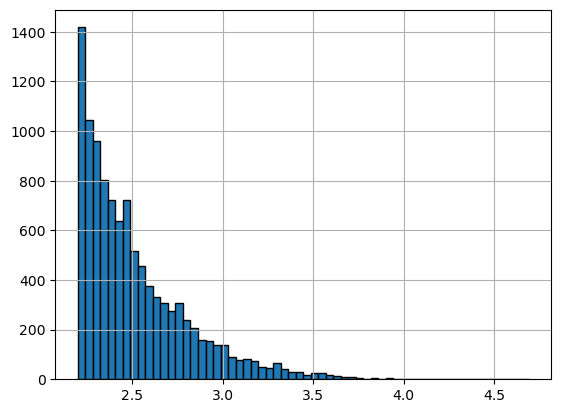

In [14]:
df[df['Magnitude'] >= 2.2]['Magnitude'].hist(bins=60, edgecolor='black')


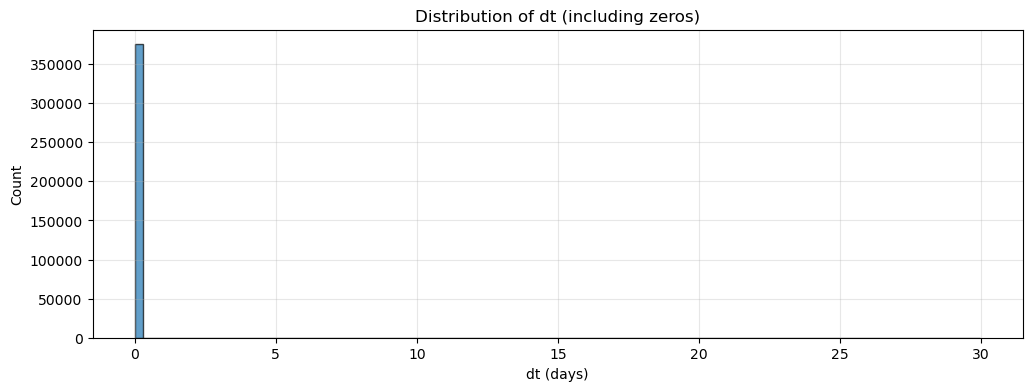

In [15]:
dt = filtered_df['dt']
fig_dt, (ax_lin) = plt.subplots(1, 1, figsize=(12, 4))

ax_lin.hist(dt, bins=100, color='C0', edgecolor='k', alpha=0.7)
ax_lin.set_title("Distribution of dt (including zeros)")
ax_lin.set_xlabel("dt (days)")
ax_lin.set_ylabel("Count")
ax_lin.grid(True, alpha=0.3)

In [16]:
df.loc[filtered_df['dt'].idxmax()]


t                            518.774588
Magnitude                          1.83
Latitude                        38.8149
Longitude                     -122.8278
Depth                              3.36
ts           2004-09-30 18:35:24.400000
dt                            29.975141
Name: 12895, dtype: object

In [17]:
df.loc[df['dt'].idxmax()-3:df['dt'].idxmax()+3]

,t,Magnitude,Latitude,Longitude,Depth,ts,dt
12892,488.623210,0.80,38.7566,-122.7084,0.00,2004-08-31 14:57:25.380,0.011611
12893,488.683407,1.05,38.7813,-122.7608,1.10,2004-08-31 16:24:06.400,0.060197
12894,488.799447,1.74,38.8103,-122.8107,2.01,2004-08-31 19:11:12.200,0.116039
12895,518.774588,1.83,38.8149,-122.8278,3.36,2004-09-30 18:35:24.400,29.975141
12896,518.823477,2.09,38.8357,-122.8034,3.00,2004-09-30 19:45:48.400,0.048889
12897,518.881451,1.47,38.7132,-122.6827,2.50,2004-09-30 21:09:17.330,0.057974
12898,519.018599,1.35,38.7899,-122.7361,2.13,2004-10-01 00:26:46.970,0.137149


In [18]:
Inj_per_month = Inj.set_index('Date').resample('ME').sum()[['InjVol', 'ProdVol']]
events_per_month = filtered_df.set_index('ts').resample('ME').size()

In [19]:
# 合并按月注入/生产与地震事件数，生成 monthly 供下游绘图使用
monthly = Inj_per_month.copy()
monthly['events'] = events_per_month.reindex(monthly.index).fillna(0).astype(int)
monthly['events_MA12'] = monthly['events'].rolling(12, min_periods=1).mean()
monthly.head()

,InjVol,ProdVol,events,events_MA12
Date,,,,
2003-05-31,33.01976,50.74228,547,547.0
2003-06-30,18.73602,50.75838,471,509.0
2003-07-31,14.39230,52.34909,395,471.0
2003-08-31,15.79554,51.50224,403,454.0
2003-09-30,15.31483,49.49692,449,453.0


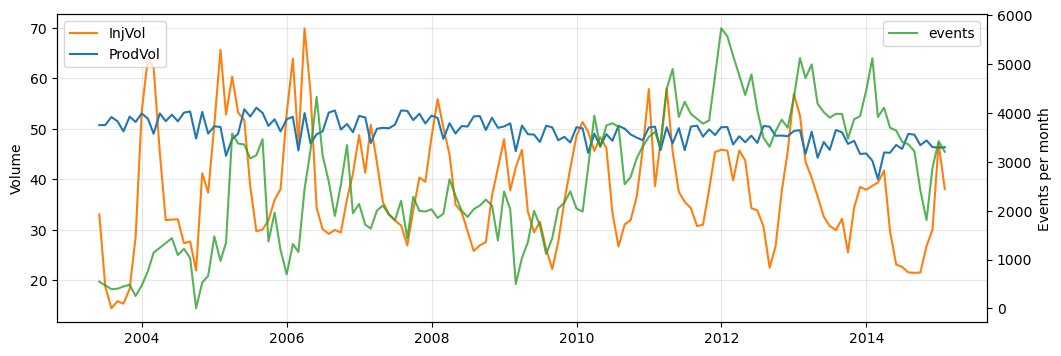

In [20]:
fig, ax1 = plt.subplots(figsize=(12,4))

# volumes on left axis
ax1.plot(monthly.index, monthly['InjVol'], label='InjVol', color='C1')
ax1.plot(monthly.index, monthly['ProdVol'], label='ProdVol', color='C0')
ax1.set_ylabel('Volume')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# events on right axis
ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly['events'], label='events', color='C2', alpha=0.8)
# optional 12-month MA for events if present
# if 'events_MA12' in monthly.columns:
#     ax2.plot(monthly.index, monthly['events_MA12'], '--', label='events MA12', color='C3', alpha=0.7)
ax2.set_ylabel('Events per month')
ax2.legend(loc='upper right')



In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

n = len(monthly)
n_train = int(n * 0.8)

X_train = X.iloc[:n_train]
X_test = X.iloc[n_train:]
y_train = y.iloc[:n_train]
y_test = y.iloc[n_train:]

NameError: name 'X' is not defined

                  r2_train   r2_test     mae_test
model                                            
LinearRegression  0.103813 -1.764213  1033.687669
Lasso (scaled)    0.103813 -1.764247  1033.694720
Ridge (scaled)    0.103807 -1.777010  1036.547104
RandomForest      0.885260 -4.113142  1408.341724
GradientBoosting  0.983388 -4.836097  1415.898701
SVR (RBF scaled) -0.047410 -5.791830  1745.058844


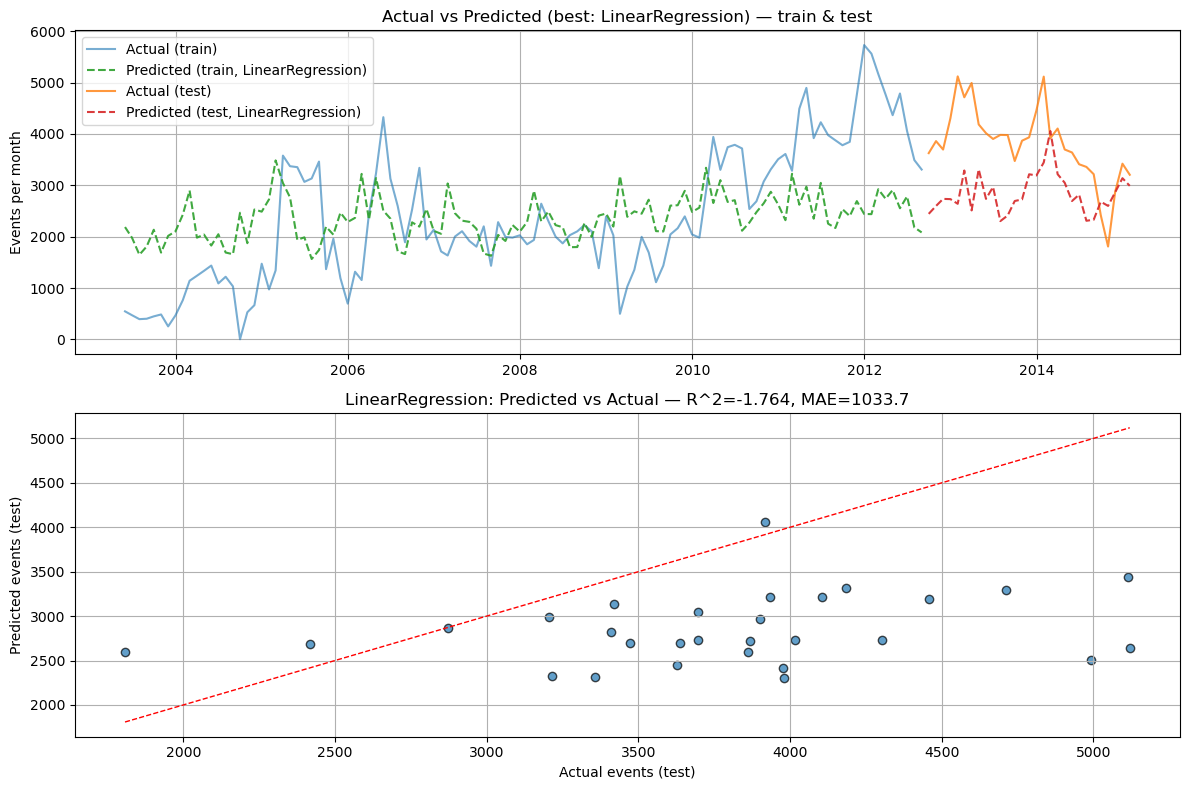

In [ ]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

models = {
    "LinearRegression": LinearRegression(),
    "Ridge (scaled)": make_pipeline(StandardScaler(), Ridge(alpha=1.0, random_state=0)),
    "Lasso (scaled)": make_pipeline(StandardScaler(), Lasso(alpha=0.01, random_state=0, max_iter=10000)),
    "SVR (RBF scaled)": make_pipeline(StandardScaler(), SVR(kernel='rbf', C=1.0, epsilon=0.1)),
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=0),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=200, random_state=0)
}

results = []
preds_test = {}
preds_train = {}

for name, mdl in models.items():
    try:
        mdl.fit(X_train, y_train)
        y_pred_train = pd.Series(mdl.predict(X_train), index=X_train.index)
        y_pred_test = pd.Series(mdl.predict(X_test), index=X_test.index)

        r2_tr = r2_score(y_train, y_pred_train)
        r2_te = r2_score(y_test, y_pred_test)
        mae_te = mean_absolute_error(y_test, y_pred_test)

        results.append((name, r2_tr, r2_te, mae_te))
        preds_train[name] = y_pred_train
        preds_test[name] = y_pred_test
    except Exception as e:
        # keep record and continue
        results.append((name, float('nan'), float('nan'), float('nan')))
        print(f"Model {name} failed: {e}")

results_df = pd.DataFrame(results, columns=["model", "r2_train", "r2_test", "mae_test"]).set_index("model")
results_df = results_df.sort_values("r2_test", ascending=False)
print(results_df)

best_model = results_df.index[0]
r2_best = results_df.loc[best_model, "r2_test"]
mae_best = results_df.loc[best_model, "mae_test"]

# Plot time series (train+test) and scatter for best model
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# time series: actual and predicted
ax1.plot(y_train.index, y_train.values, label='Actual (train)', color='C0', alpha=0.6)
if best_model in preds_train:
    ax1.plot(preds_train[best_model].index, preds_train[best_model].values, '--', label=f'Predicted (train, {best_model})', color='C2', alpha=0.9)

ax1.plot(y_test.index, y_test.values, label='Actual (test)', color='C1', alpha=0.8)
if best_model in preds_test:
    ax1.plot(preds_test[best_model].index, preds_test[best_model].values, '--', label=f'Predicted (test, {best_model})', color='C3', alpha=0.9)

ax1.set_title(f'Actual vs Predicted (best: {best_model}) — train & test')
ax1.set_ylabel('Events per month')
ax1.legend()
ax1.grid(True)

# scatter: test actual vs predicted
if best_model in preds_test:
    ax2.scatter(y_test, preds_test[best_model], alpha=0.7, edgecolors='k')
    mn = min(y_test.min(), preds_test[best_model].min())
    mx = max(y_test.max(), preds_test[best_model].max())
    ax2.plot([mn, mx], [mn, mx], 'r--', linewidth=1)
    ax2.set_xlabel('Actual events (test)')
    ax2.set_ylabel('Predicted events (test)')
    ax2.set_title(f'{best_model}: Predicted vs Actual — R^2={r2_best:.3f}, MAE={mae_best:.1f}')
    ax2.grid(True)

plt.tight_layout()
plt.show()